
Model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

 Distinction       0.45      0.85      0.59       605
        Fail       0.82      0.84      0.83      1411
        Pass       0.85      0.65      0.74      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.82      6519
   macro avg       0.78      0.84      0.79      6519
weighted avg       0.85      0.82      0.82      6519



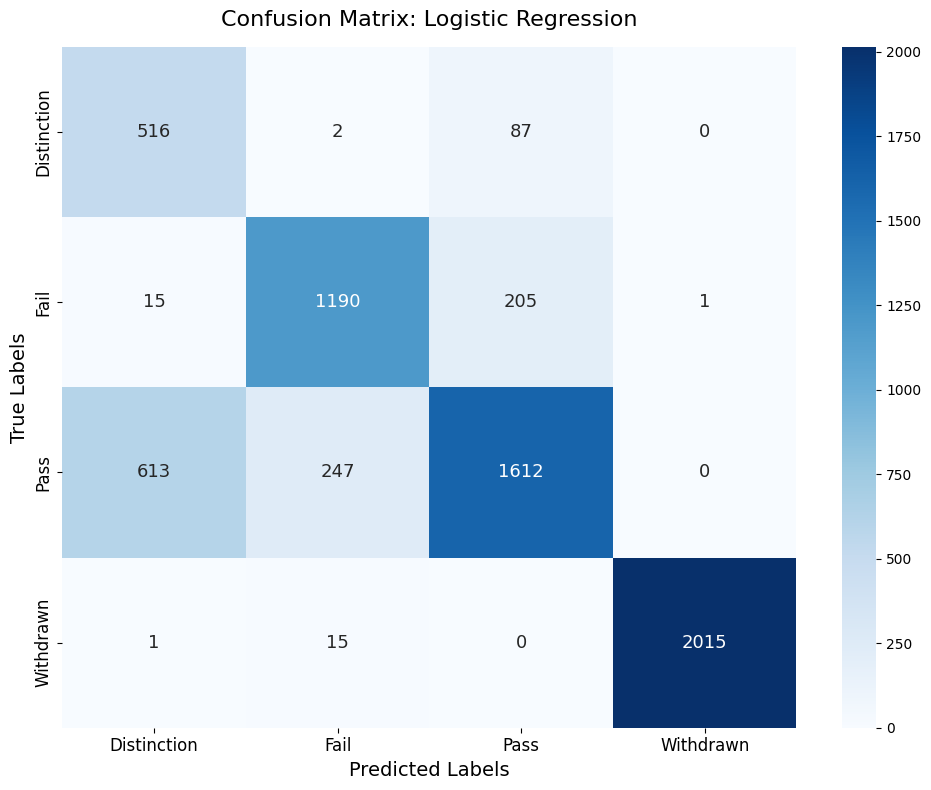


Model: Random Forest
Classification Report:
              precision    recall  f1-score   support

 Distinction       0.72      0.47      0.57       605
        Fail       0.92      0.79      0.85      1411
        Pass       0.79      0.92      0.85      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.87      6519
   macro avg       0.86      0.79      0.82      6519
weighted avg       0.88      0.87      0.87      6519



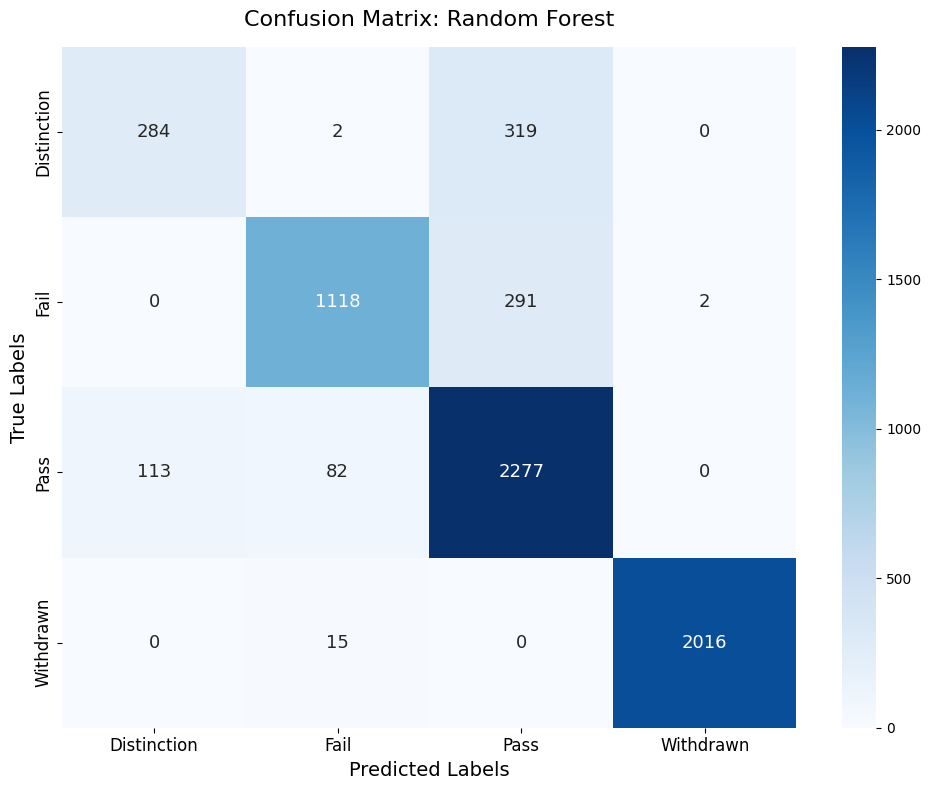


Model: XGBoost
Classification Report:
              precision    recall  f1-score   support

 Distinction       0.68      0.53      0.59       605
        Fail       0.91      0.80      0.85      1411
        Pass       0.80      0.90      0.85      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.87      6519
   macro avg       0.85      0.80      0.82      6519
weighted avg       0.87      0.87      0.87      6519



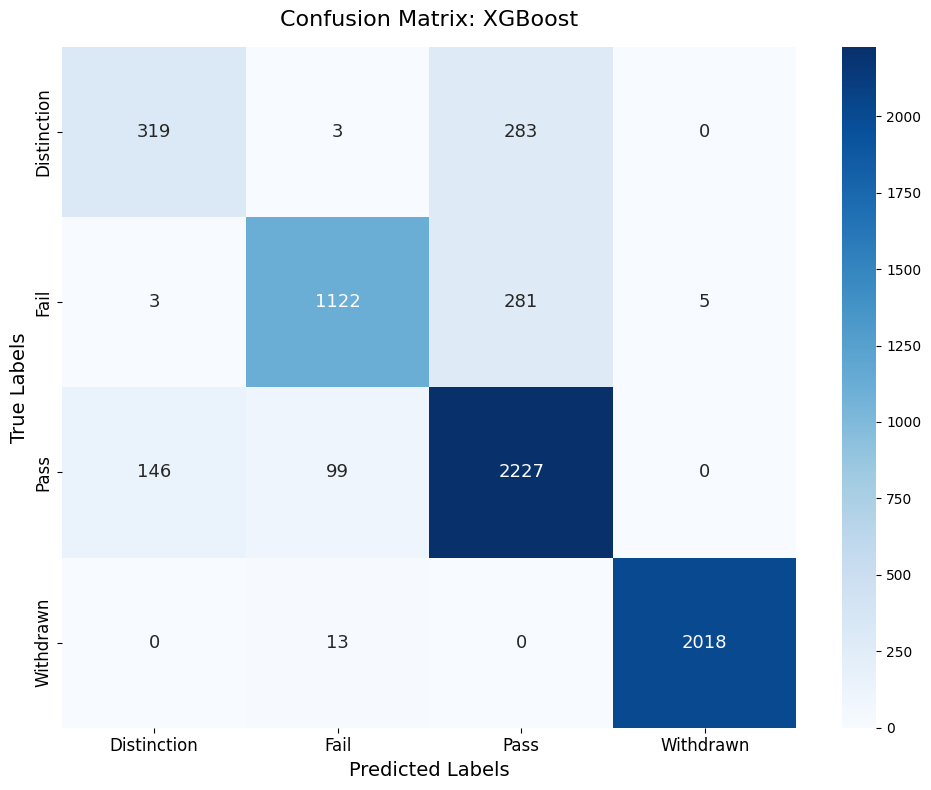


Model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

 Distinction       0.53      0.53      0.53       605
        Fail       0.81      0.79      0.80      1411
        Pass       0.78      0.79      0.79      2472
   Withdrawn       0.99      0.99      0.99      2031

    accuracy                           0.83      6519
   macro avg       0.78      0.78      0.78      6519
weighted avg       0.83      0.83      0.83      6519



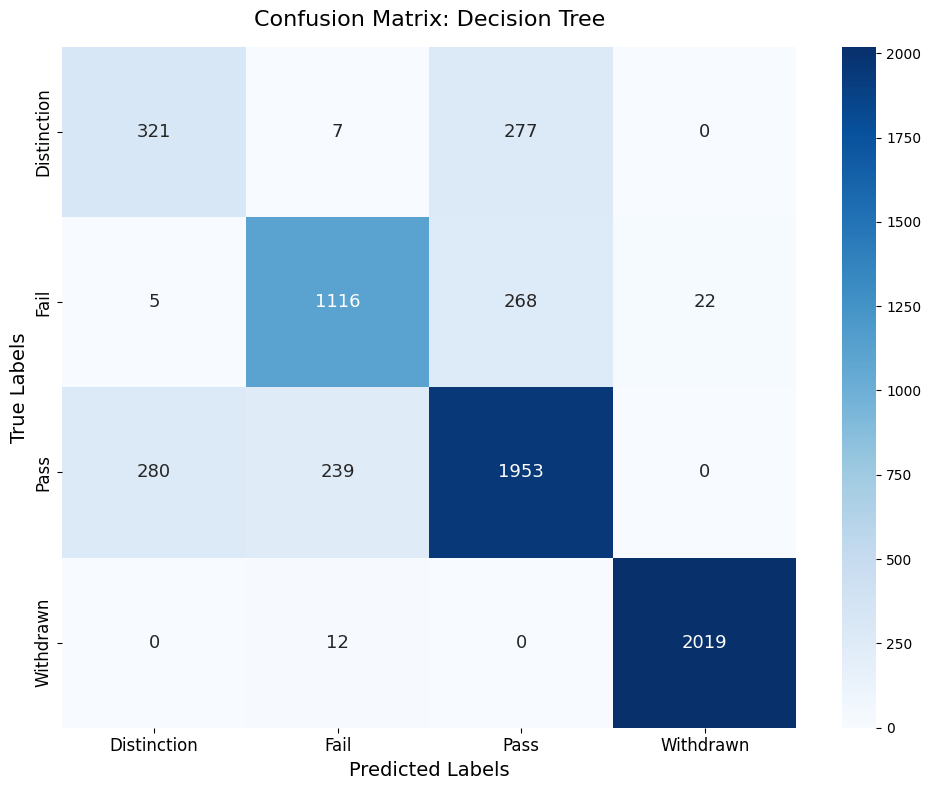

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('final_data.csv')
df = df.dropna()

categorical_cols = df.select_dtypes(include=['object']).columns.drop('final_result', errors='ignore')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

le_target = LabelEncoder()
df['final_result'] = le_target.fit_transform(df['final_result'].astype(str))
target_names = le_target.classes_

X = df.drop(columns=['id_student', 'final_result'], errors='ignore')
y = df['final_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\nModel: {name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("="*60)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, 
                cbar=True, annot_kws={"size": 13})
    
    plt.title(f"Confusion Matrix: {name}", fontsize=16, pad=15)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(rotation=90, fontsize=12)
    
    plt.tight_layout()
    plt.show()

Epoch [10] | Loss: 0.3057 | LR: 0.001000
Epoch [20] | Loss: 0.2885 | LR: 0.001000
Epoch [30] | Loss: 0.2712 | LR: 0.001000
Epoch [40] | Loss: 0.2601 | LR: 0.001000
Epoch [50] | Loss: 0.2393 | LR: 0.000500
Epoch [60] | Loss: 0.2298 | LR: 0.000500
Epoch [70] | Loss: 0.2245 | LR: 0.000500
Epoch [80] | Loss: 0.2168 | LR: 0.000500
Epoch [90] | Loss: 0.2108 | LR: 0.000250
Epoch [100] | Loss: 0.2098 | LR: 0.000125
Epoch [110] | Loss: 0.1964 | LR: 0.000125
Epoch [120] | Loss: 0.1894 | LR: 0.000031
Epoch [130] | Loss: 0.1889 | LR: 0.000031
Epoch [140] | Loss: 0.1889 | LR: 0.000008
Early stopping tại epoch 143

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Distinction       0.46      0.82      0.59       605
        Fail       0.78      0.88      0.82      1411
        Pass       0.86      0.64      0.74      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.82      6519
   macro avg       0.78      0.83      0.79

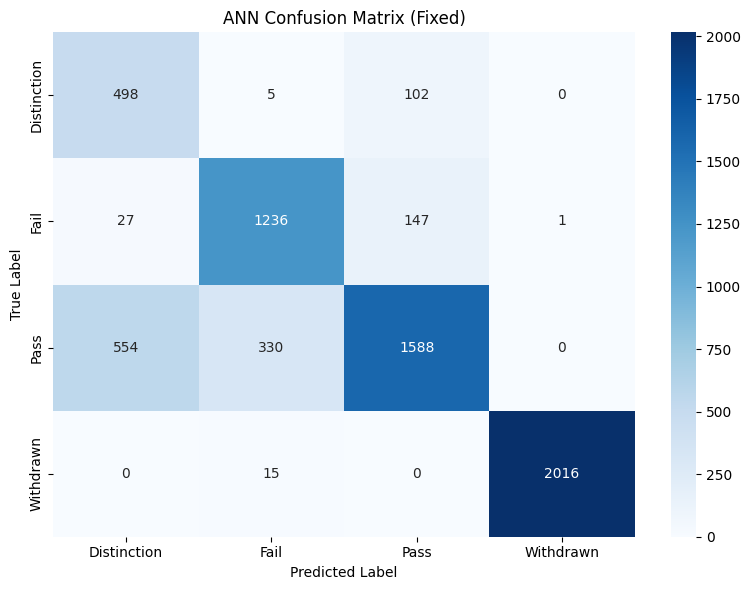

In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_data.csv')
df = df.drop(columns=['id_student'])

X = df.drop(columns=['final_result'])
y = df['final_result']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
target_names = label_encoder.classes_

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded  # ✅ thêm stratify
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.LongTensor(y_test)

# ✅ WeightedRandomSampler: oversample minority classes trong mỗi batch
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = torch.FloatTensor([class_weights[label] for label in y_train])
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=64, sampler=sampler)  # ❌ bỏ shuffle khi dùng sampler

# ✅ Model sâu hơn + BatchNorm + Dropout tăng dần
class TabularANN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(TabularANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_scaled.shape[1]
model = TabularANN(input_dim, num_classes)

# ✅ Class weights cho loss function (kết hợp cả 2 cách xử lý imbalance)
weights_tensor = torch.FloatTensor(class_weights)
criterion  = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer  = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ✅ Learning rate scheduler: giảm lr khi loss không cải thiện
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# ✅ Tăng epochs + early stopping đơn giản
epochs = 200
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)

    # Early stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')  # lưu model tốt nhất
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping tại epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}] | Loss: {avg_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# ✅ Load lại model tốt nhất để evaluate
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, y_pred_classes = torch.max(test_outputs, 1)

y_pred_classes = y_pred_classes.numpy()
y_test_numpy   = y_test_tensor.numpy()

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_numpy, y_pred_classes, target_names=target_names))

cm = confusion_matrix(y_test_numpy, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ANN Confusion Matrix (Fixed)')
plt.tight_layout()
plt.show()